<a href="https://colab.research.google.com/github/omazevych/python_for_da_tasks/blob/main/Final_Project_Sports_Footwear_Sales_%26_Consumer_Behavior_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sports Footwear Sales & Consumer Behavior(2018–2026)

📊 Опис проєкту

Цей проєкт присвячений аналізу даних продажів спортивного взуття з метою дослідження факторів, що впливають на виручку, поведінку клієнтів та ефективність бізнес-стратегій.

Мета проєкту

Основною метою є отримання бізнес-інсайтів, які допоможуть:

- підвищити виручку та середній чек;
- оптимізувати асортимент продукції;
- покращити ефективність маркетингових стратегій;
- краще зрозуміти поведінку клієнтів у різних сегментах.

Аналіз охоплює:
- динаміку та структуру продажів;
- вплив брендів і категорій на виручку;
- поведінку клієнтів за рівнем доходу, країною та каналом продажу;
- ефективність знижок та цінової політики;
- вплив способів оплати на поведінку покупців;
- задоволеність клієнтів (customer rating);
- статистичні перевірки гіпотез (t-test, ANOVA, χ²-тести).

Цілі аналізу
1. Дослідити структуру попиту на спортивне взуття.
2. Визначити ключові драйвери виручки (бренд, категорія, канал продажу).
3. Проаналізувати поведінку клієнтів у різних країнах та сегментах доходу.
4. Виявити потенційні можливості для зростання бізнесу та оптимізації продажів.


# Опис даних

Цей набір даних містить реальні дані про продажі, ціни та споживачів спортивного взуття з 2018 по 2026 рік. Він охоплює кілька світових брендів таких як Nike, Adidas, Puma, Reebok, ASICS, New Balance.


**Опис колонок:**
- `order_id` - Унікальний ідентифікатор для кожної продажі 🆔
- `order_date` - Дата продажу 📅
- `brand` - Бренд взуття 👟
- `model_name` - Конкретна модель взуття 🏷️
- `category` - Категорія взуття: Біг, Тренування, Баскетбол, Стиль життя, Тренажерний зал 🏃‍♂️
- `gender` - Гендерна приналежність взуття: Чоловіки, Жінки, Унісекс 🚹🚺
- `size` - Розмір взуття 👞
- `color` - Колір взуття 🎨
- `base_price_usd(in USD)` - Початкова ціна 💵
- `discount_percent(%)` - ​Застосована знижка  🔖
- `final_price_usd` - Ціна після знижки 💰
- `units_sold` - Продана кількість 📦
- `revenue_usd` - Загальний дохід за замовлення 📊
- `payment_method` - Оплата: Картка, Готівка, Гаманець, Банківський переказ 💳
- `sales_channel` - Канал продажу: Інтернет-магазин / Роздрібний магазин 🌐🏬
- `country` - Країна продажу 🌎
- `customer_income_level` - Рівень доходу клієнта: Низький / Середній / Високий 💼
- `customer_rating` - Середня оцінка від 3.0 до 5.0 ⭐



# Завантаження набору даних

In [1]:
# Завантаження необхідних біблотек та набору даних
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('drive/MyDrive/Data Analysis/global_sports_footwear_sales_2018_2026.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Огляд набору даних
print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])

Кількість рядків: 30000
Кількість колонок: 18


In [3]:
df

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.70,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.00,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.40,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.70,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.00,Cash,Online,USA,Medium,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,ORD129995,2018-05-28,Puma,Model-892,Gym,Women,6,Blue,140,10,126.00,1,126.00,Card,Online,UAE,High,4.3
29996,ORD129996,2018-04-28,Adidas,Model-982,Running,Women,9,Grey,113,15,96.05,1,96.05,Card,Online,UK,High,3.5
29997,ORD129997,2026-02-17,ASICS,Model-463,Basketball,Men,11,Blue,130,30,91.00,1,91.00,Wallet,Online,India,Medium,4.4
29998,ORD129998,2024-02-21,New Balance,Model-984,Running,Unisex,11,White,186,10,167.40,2,334.80,Wallet,Retail Store,USA,High,3.9


In [4]:
# переглянемо типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

**Висновки:**

*Отже, наш  набір даних містить 30000 рядків та  18 колонок.*

# Перевірка даних перед початком роботи

*Перевіримо чи містить набір порожні значення і дублікати.*



In [5]:
# перевірка на відсутні значення
df.isnull().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [6]:
# перевірка на дублікати
df[df.duplicated()]

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating


In [7]:
# статистика для категоріальних колонок
df.describe(include="O")

,order_id,order_date,brand,model_name,category,gender,color,payment_method,sales_channel,country,customer_income_level
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,30000,3287,6,899,5,3,5,4,2,6,3
top,ORD129983,2022-09-20,ASICS,Model-863,Basketball,Men,Grey,Bank Transfer,Retail Store,UAE,High
freq,1,21,5132,53,6074,10075,6046,7686,15009,5118,10059


**Висновки:**

1. Датасет добре збалансований по розміру, немає пропусків та дублікатів, тож дані придатні для сегментації.
2. Набір брендів не надто широкий, але достатній для аналізу трендів. Всього 6 брендів, ASICS є одним із лідерів продажів: частота 5132 замовлення (~17.1%).
3. Дуже широкий модельний ряд спортивного взуття: 899 моделей, найпопулярніша Model-863.
4. Найпопулярніша категорія - взуття для баскетболу, де частота 6074 (~20.2%).
5. Чоловіки набільше купують взуття, але варто відмітити, що у нас лише 3 категорії і важко виокремити стать з унісекс моделей.
6. ОАЕ є найбільшим ринком спортивного взуття серед представлених країн, також покупці обирають купувати в фізичних магазинах(хоча перевага незначна, майже рівний поділ) і оплату карткою.

In [8]:
 # статистика для всіх числових колонок
df.drop(columns=['order_id']).describe().round(2)

,size,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,customer_rating
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,8.50,139.63,13.33,121.03,2.50,302.71,4.00
std,1.71,46.06,9.86,42.51,1.12,179.15,0.58
min,6.00,60.00,0.00,42.00,1.00,42.00,3.00
25%,7.00,100.00,5.00,85.00,1.00,156.75,3.50
50%,9.00,140.00,10.00,119.20,3.00,268.20,4.00
75%,10.00,180.00,20.00,153.60,4.00,414.00,4.50
max,11.00,219.00,30.00,219.00,4.00,876.00,5.00


**Висновки**

1. Найпопулярніші розміри 8-10 і це означає, що саме ці розміри варто підтримувати у найбільшому запасі в магазинах та на складах.
2. Орієнтуючись на базову ціну, варто відмітити, що середнє та медіана  майже збігаються, тож розподіл цін досить симетричний і не має сильних викидів.
Основний асортимент знаходиться в діапазоні: від 100 до 180 USD(між 25% і 75%).
3. Загальна задоволеність клієнтів висока, де середня оцінка = 4, а 75% оцінок ≥ 4.5. Це свідчить про позитивний клієнтський досвід.
4. Покупці купують більше 1 товару, і зі знижкою, де типовий дисконт 10%.


# Бізнес питання аналізу

###**1. 👟 Які з брендів спортивного взуття найпопулярніші?**

/tmp/ipykernel_73423/4062866175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


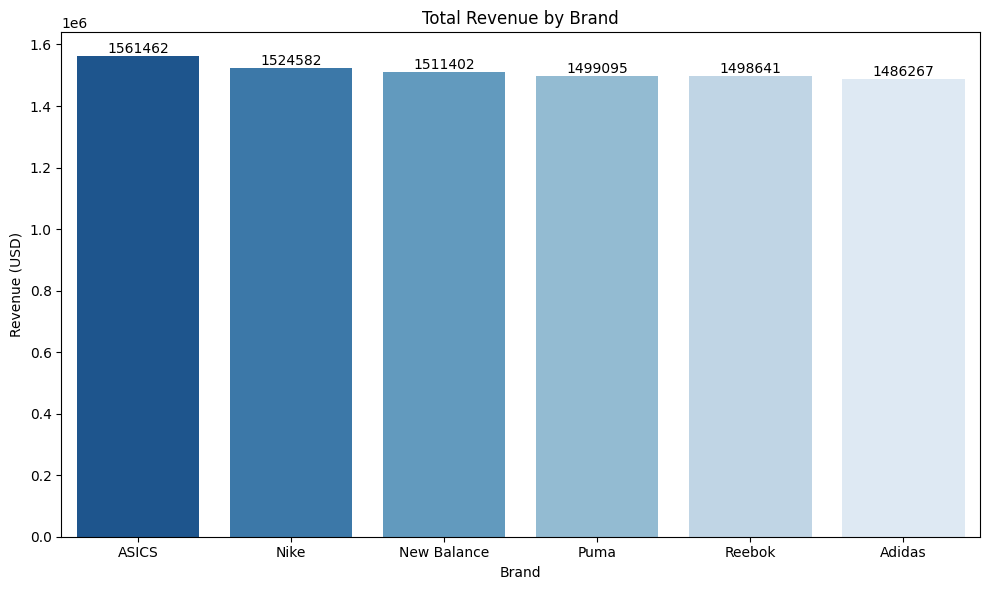

In [9]:
#  Загальна виручка за брендами
brand_revenue = (
    df.groupby("brand")["revenue_usd"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=brand_revenue.index,
    y=brand_revenue.values,
    palette="Blues_r"
)

plt.title("Total Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue (USD)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

In [10]:
pd.pivot_table(
    df,
    values="revenue_usd",
    index="brand",
    columns="category",
    aggfunc="sum"
)

category,Basketball,Gym,Lifestyle,Running,Training
brand,,,,,
ASICS,309239.85,308507.10,330533.70,303161.40,310020.45
Adidas,303302.80,286741.15,300987.10,291800.85,303434.65
New Balance,298548.70,286737.15,295559.55,308533.05,322023.05
Nike,312283.10,300273.65,300541.80,296921.30,314562.25
Puma,304181.10,292576.05,318943.60,295246.95,288147.20
Reebok,294814.10,297825.60,298063.00,309787.15,298151.05


 **Висновки:**

*Лідерами з продажу є бренди ASICS та Nike, хоча інші 4 бренди не пасуть задніх. Аналіз виручки за брендами та категоріями показує відсутність монополії на ринку спортивного взуття. Кожен бренд має власну спеціалізацію: Nike домінує у Basketball, ASICS демонструє стабільні показники у всіх категоріях, а найкращий у Lifestyle, а New Balance лідирує у Training та Running. Це свідчить про чітку сегментацію ринку та відсутність універсального лідера.*

###**2. 🏃‍♂️ Які категорії найбільш уподобані серед покупців спортивного взуття?**

In [11]:
# Які категорії купують клієнти з різним доходом.
pd.pivot_table(
    df,
    values="revenue_usd",
    index="customer_income_level",
    columns="category",
    aggfunc="sum"
)

category,Basketball,Gym,Lifestyle,Running,Training
customer_income_level,,,,,
High,621643.20,582129.85,621808.35,587281.85,624941.05
Low,594144.90,602886.45,609605.80,624397.85,609546.20
Medium,606581.55,587644.40,613214.60,593771.00,601851.40


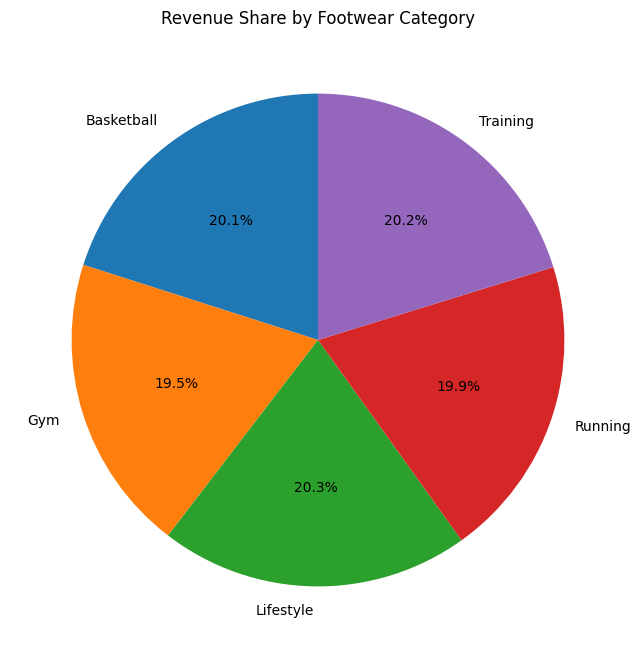

In [12]:
# 2. Cтруктура загальної виручки по категоріям
category_revenue = (
    df.groupby("category")["revenue_usd"]
      .sum()
)

plt.figure(figsize=(8,8))
plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Footwear Category")
plt.show()

**Висновки:**

*Майже рівномірний розподіл серед уподобань покупців, хоча все ж найбільше покупці купують взуття категорій Lifestyle, Training, Basketball, що свідчить, що люди обирают комфортне взуття для повсягдення. Аналіз виручки за категоріями та рівнем доходу клієнтів показує відсутність суттєвої залежності між доходом і загальною сумою покупок. Усі три сегменти (High, Medium, Low) генерують приблизно однакову виручку, що свідчить про масовий характер попиту на спортивне взуття.*

###**3. 🌎 Які країни з найбільшою виручкою?**

/tmp/ipykernel_73423/459461612.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


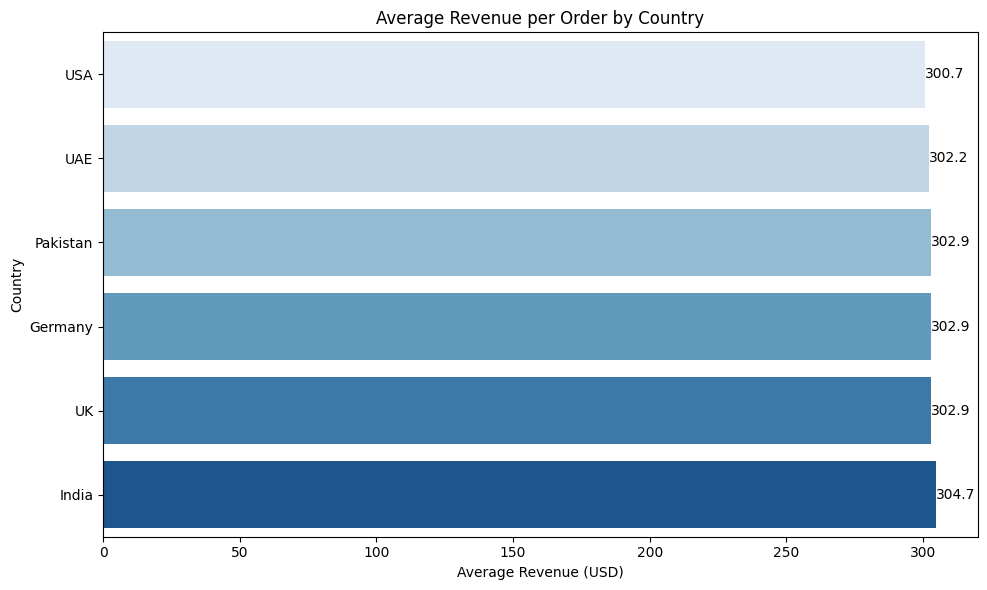

In [13]:
# 3. Середня виручка замовлення за країнами
country_avg = (
    df.groupby("country")["revenue_usd"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=country_avg.values,
    y=country_avg.index,
    palette="Blues"
)

plt.title("Average Revenue per Order by Country")
plt.xlabel("Average Revenue (USD)")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

**Висновки:**

*Лідерами з продажу спортивного взуття є Індія, Пакистан та Велика Британія з Німеччиною, які мають однаковий обсяг середньої виручки. Ймовірно 2 азійські країни потрапили в рейтинг як найбільші виробники взуття, а 2 європейські , як одні з найбільших ринків збуту спортивного одягу та взуття.*

###**4. 🚺 Чи відрізняються вподобання по категоріям серед чоловіків та жінок?**

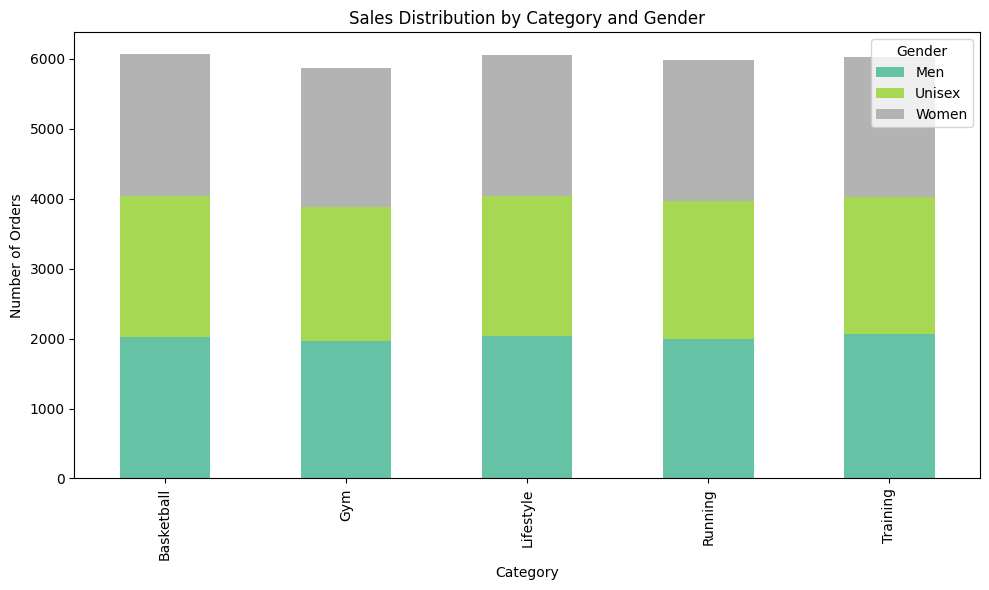

In [14]:
# Обсяг продажів категорій та структура за гендером
gender_category = pd.crosstab(
    df["category"],
    df["gender"]
)

gender_category.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set2"
)

plt.title("Sales Distribution by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

**Висновки:**

*Продажі рівномірно розподілені між усіма категоріями, без явного домінування однієї з них. У кожній категорії найбільшу кількість замовлень формує чоловічий сегмент, тоді як Unisex залишається найменшим. Гендерна структура продажів є стабільною між категоріями, що свідчить про відсутність суттєвих відмінностей у вподобаннях покупців залежно від типу спортивного товару. Це може вказувати на збалансований продуктовий портфель компанії та відсутність критичної залежності від окремого сегмента клієнтів.*



###**5. 💳 Чи простежуюься платіжні звички клієнтів залежно від каналу продажу?**

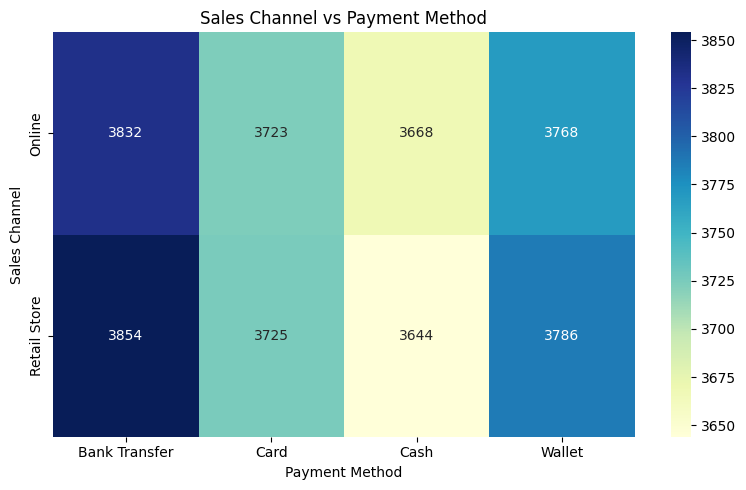

In [15]:
# Оцінюємо комбінації двох категоріальних змінних.
payment_channel = pd.crosstab(
    df["sales_channel"],
    df["payment_method"]
)

plt.figure(figsize=(8,5))

sns.heatmap(
    payment_channel,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Sales Channel vs Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales Channel")

plt.tight_layout()
plt.show()

**Висновки**

*Клієнти найчастіше обирають оплати Bank Transfer незалежно від того у фізичному магазині чи онлайн вони купують товари, рідше оплачують готівкою.*

###**6. 🏷️ Які ТОП-10 моделей спортивного взуття?**

/tmp/ipykernel_73423/4251506095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


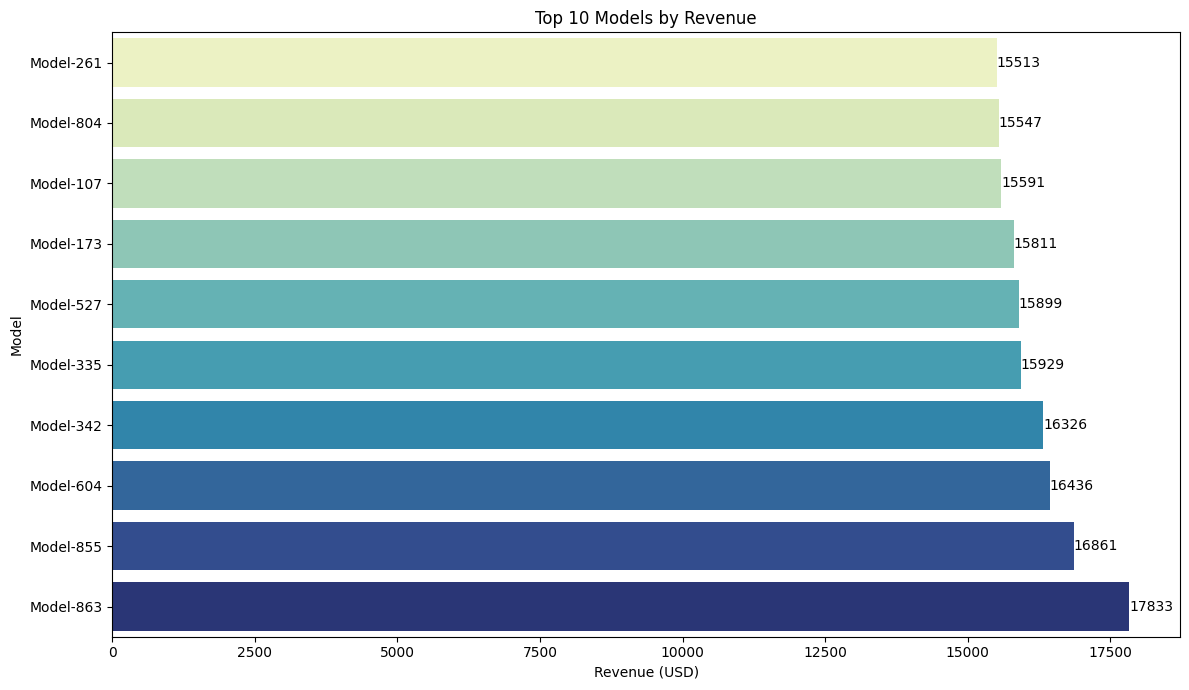

In [16]:
top_models = (
    df.groupby("model_name")["revenue_usd"]
      .sum()
      .nlargest(10)
      .sort_values()
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_models.values,
    y=top_models.index,
    palette="YlGnBu"
)

plt.title("Top 10 Models by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

**Висновки:**

*Безумовним лідером серед понад 800 моделей спортивного взуття є Model-863.*

###**7. ⭐ Яку оцінку в середньому отримують бренди від покупців?**

In [17]:
# Середня оцінка брендів по країнах
pd.pivot_table(
    df,
    values="customer_rating",
    index="brand",
    columns="country",
    aggfunc="mean"
)

country,Germany,India,Pakistan,UAE,UK,USA
brand,,,,,,
ASICS,4.011379,3.992073,4.018350,4.021820,4.025534,3.985231
Adidas,3.962454,3.986300,3.989767,4.010936,4.013269,3.965455
New Balance,4.010798,3.996707,4.014055,3.988120,3.969870,4.012605
Nike,3.995140,3.973929,3.984615,4.004540,4.035386,3.993031
Puma,4.019312,4.010731,4.007613,4.020862,3.982572,3.976374
Reebok,4.004394,4.028889,4.023759,4.006904,4.000000,4.009922


/tmp/ipykernel_73423/2752255915.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


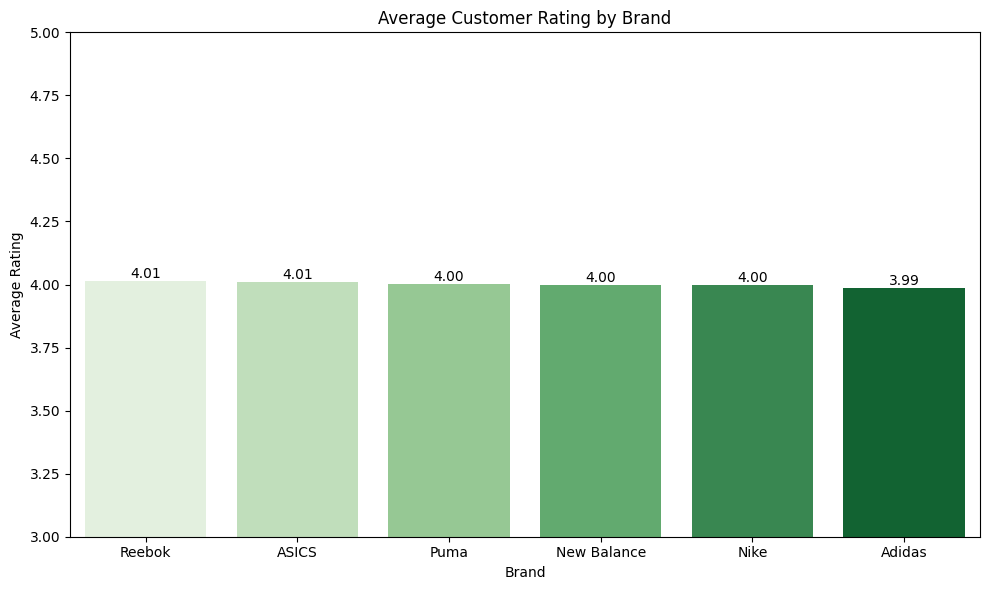

In [18]:
# Порівняння середніх значень між брендами.
brand_rating = (
    df.groupby("brand")["customer_rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=brand_rating.index,
    y=brand_rating.values,
    palette="Greens"
)

plt.title("Average Customer Rating by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.ylim(3,5)

plt.tight_layout()
plt.show()

**Висновки:**

*Клієнти оцінили якість брендів у 4 ⭐, що є гарним показником. Дуже мала різниця між середніми оцінками конкурентів, і відрив незначний, хоча найгіршим брендом обрали Adidas, а найкращим - Reebok.*

###**8. 🏬 Який середній чек в залежності від каналу продажу?**

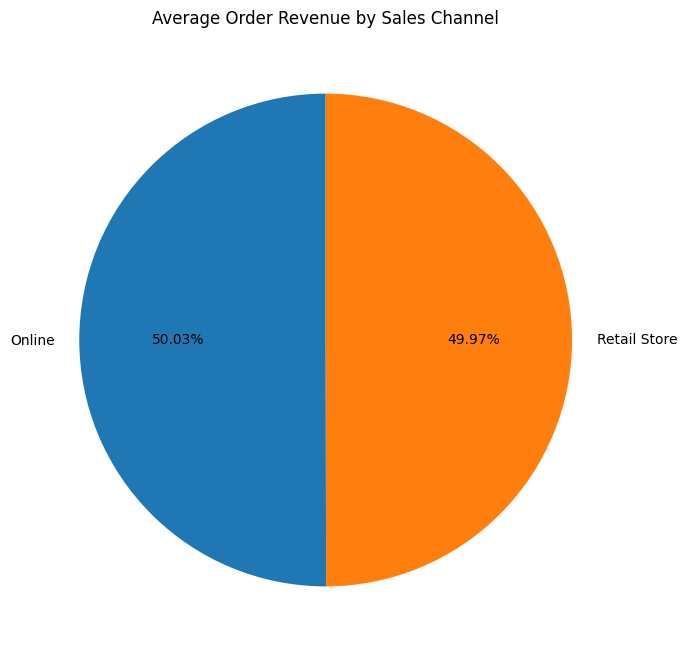

In [19]:
channel_avg = (
    df.groupby("sales_channel")["revenue_usd"]
      .mean()
)

plt.figure(figsize=(8,8))
plt.pie(
    channel_avg.values,
    labels=channel_avg.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Average Order Revenue by Sales Channel")
plt.show()

In [20]:
pd.pivot_table(
    df,
    values="revenue_usd",
    index="country",
    columns="sales_channel",
    aggfunc="mean"
)

sales_channel,Online,Retail Store
country,,
Germany,306.689333,299.046080
India,299.905374,309.506980
Pakistan,304.469271,301.302547
UAE,304.157963,300.152523
UK,303.534194,302.353749
USA,298.623411,302.835273


**Висновки:**

*Покупці однаково обирають покупки як у фізичних магазинах, та і онлайн, хоча онлайн має трошки більше уподобань. Це свідчить про стабільну цінову політику та відсутність значної сегментації клієнтів за каналами продажу. Водночас лідерство каналів змінюється залежно від країни, що може вказувати на локальні споживчі переваги та рівень розвитку e-commerce в регіонах.*

###**9. 🏬 Яку знижку всередньому надають бренди?**

/tmp/ipykernel_73423/4141543920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


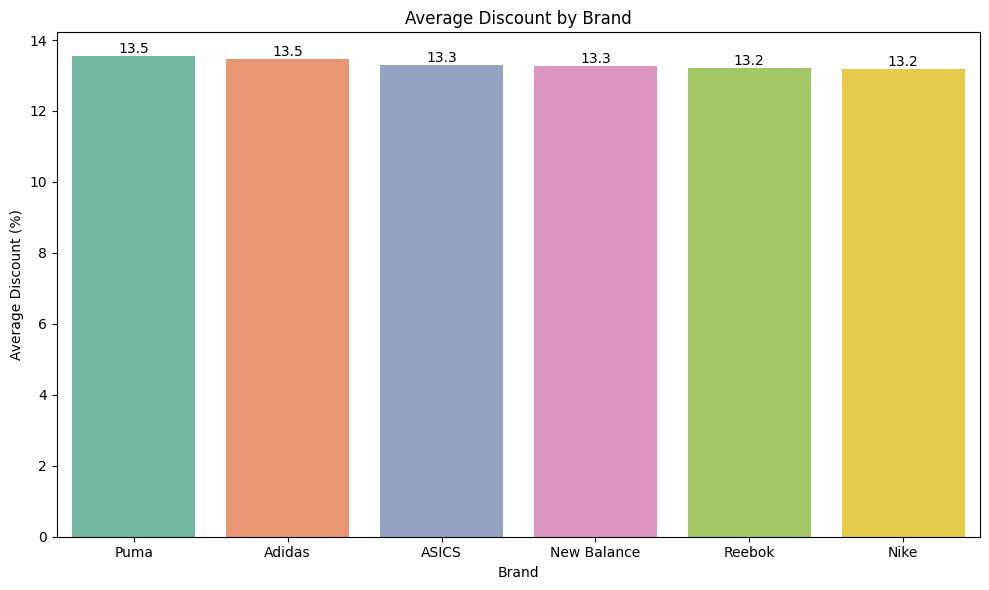

In [21]:
brand_discount = (
    df.groupby("brand")["discount_percent"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=brand_discount.index,
    y=brand_discount.values,
    palette="Set2"
)

plt.title("Average Discount by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Discount (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

**Висновки:**

*Порівнявши маркетингової політики брендів, бачимо, що в усі 6 брендів в середньому надають знижку 13%, схоже, що це тренд газузі. Ймовірно є сезонні розпродажі, але розміри знижок чітко визначені для усього ринку спортивного взуття.*

###**10. 📊 Яка динаміка виручки у часі?**

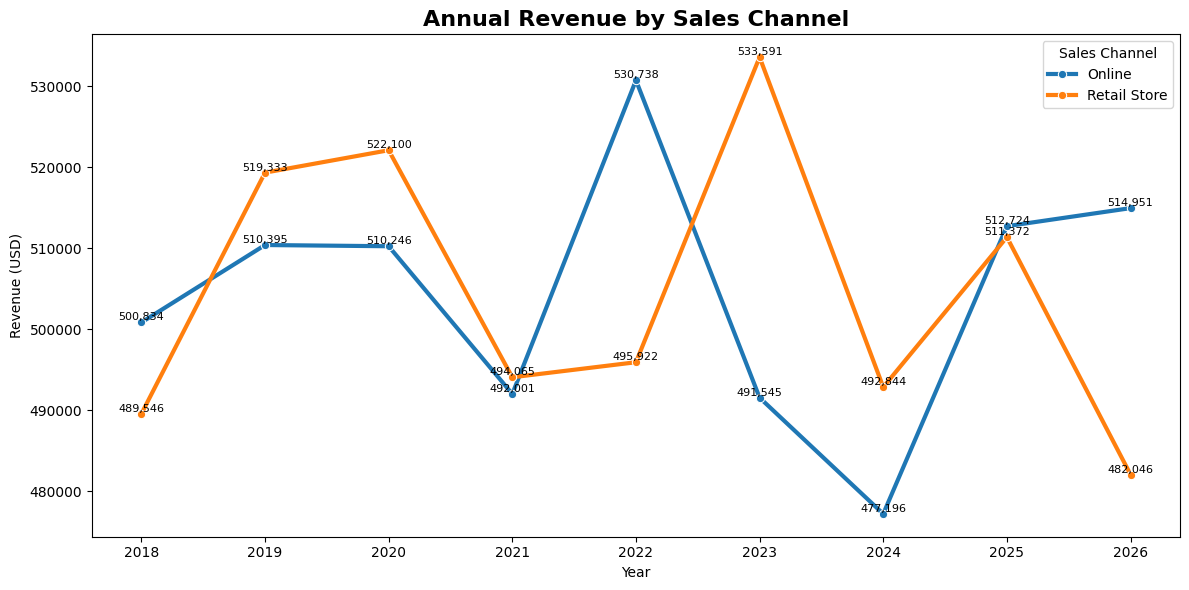

In [22]:
# Динаміка виручки у часі(щорічно)
df["order_date"] = pd.to_datetime(df["order_date"])

year_channel = (
    df.groupby(
        [df["order_date"].dt.year,
         "sales_channel"]
    )["revenue_usd"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=year_channel,
    x="order_date",
    y="revenue_usd",
    hue="sales_channel",
    marker="o",
    linewidth=3
)

plt.title(
    "Annual Revenue by Sales Channel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue (USD)")

for line in ax.lines:
    for x, y in zip(
        line.get_xdata(),
        line.get_ydata()
    ):
        plt.text(
            x,
            y,
            f'{y:,.0f}',
            fontsize=8,
            ha='center',
            va='bottom'
        )

plt.legend(title="Sales Channel")
plt.tight_layout()
plt.show()

**Висновки:**

*Відмічається певна тенденція у продажах, адже перше пожвавлення на ринку спортивного взуття було у 2019-2020, коли був період COVID-19 і люди частіше почали тренуватися вдома або ж на свіжому повітрі. у 2021 бачимо спад, який ймовірно відзначається поверненням людей на роботу в офіси після тривалого віддаленого режиму роботи. А далі йдуть роки більшої актуальності здорового стилю життя. 2024 відмічається значний спад із-за економічної ситуації у світі, подальші роки показують адаптацію клієнтів до ситуації у світі.*

*Покупки у фізичних магазинах більш популярні, що пояснюється специфікою продукту, адже взуття треба міряти та тестувати, хоча онлайн магазини мають більший асортимент та зручніші для замовлень, що пояснює їх популярність в останні роки.*

# Тестування гіпотез


####**1. Чи відрізняється середня виручка між країнами?**

Маємо більше 2 груп, тож використовуємо ANOVA. Отже, нульова гіпотеза H0: середня виручка однакова у всіх країнах, а альтернативна гіпотеза H1: хоча б одна країна відрізняється.


In [23]:
from scipy import stats

# 1. Створюємо групи по країнах
groups = [
    df[df["country"] == country]["revenue_usd"]
    for country in df["country"].unique()
]

# 2. ANOVA тест
f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# 3. Висновок
alpha = 0.05
if p_val < alpha:
    print("Висновок: Є статистично значущі відмінності між країнами.")
else:
    print("Висновок: Відмінностей між країнами не виявлено.")

F-statistic: 0.2633
P-value: 0.9332
Висновок: Відмінностей між країнами не виявлено.


/tmp/ipykernel_73423/1997049712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


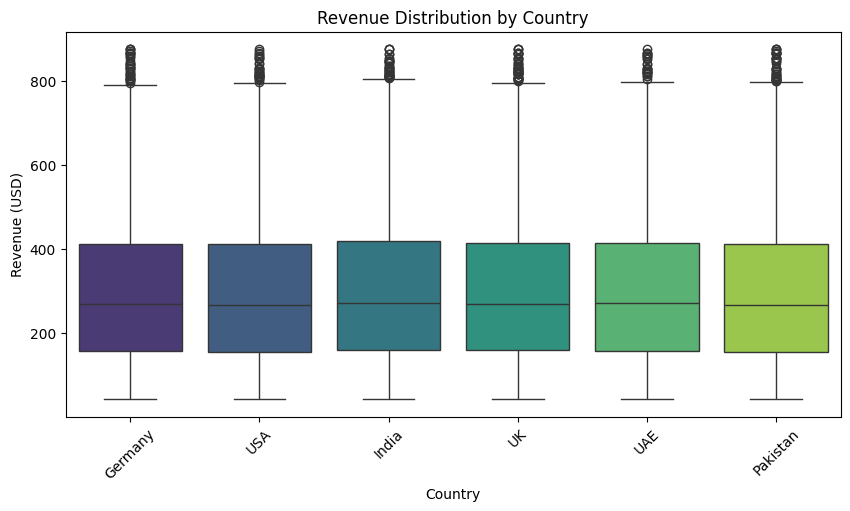

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="country",
    y="revenue_usd",
    palette="viridis"
)

plt.title("Revenue Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.show()

**Висновки:**

*P-value: 0.9332 і  відмінностей між країнами не виявлено.
Розподіл доходів є майже однаковим у всіх досліджуваних країнах. Медіанний дохід коливається біля 260–270 USD, а міжквартильний діапазон демонструє схожу варіативність у всіх ринках. У кожній країні спостерігається невелика кількість високовартісних замовлень (понад 800 USD), що формують правосторонню асиметрію розподілу. Загалом результати свідчать про схожу поведінку клієнтів між країнами та відсутність суттєвих відмінностей у структурі доходів.*

####**2. Чи є залежніст між країною та рівняем доходу клієнта?**

Отже, нульова гіпотеза H0: відсутня залежність між рівнем доходу покупців та країною, а альтернативна гіпотеза H1: залежність присутня.

In [25]:
ct = pd.crosstab(df["country"], df["customer_income_level"])

chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"Chi2-statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

alpha = 0.05
if p < alpha:
    print("Висновок: Є залежність між країною та рівнем доходу клієнта.")
else:
    print("Висновок: Залежності не виявлено.")

Chi2-statistic: 17.2261
P-value: 0.0695
Висновок: Залежності не виявлено.


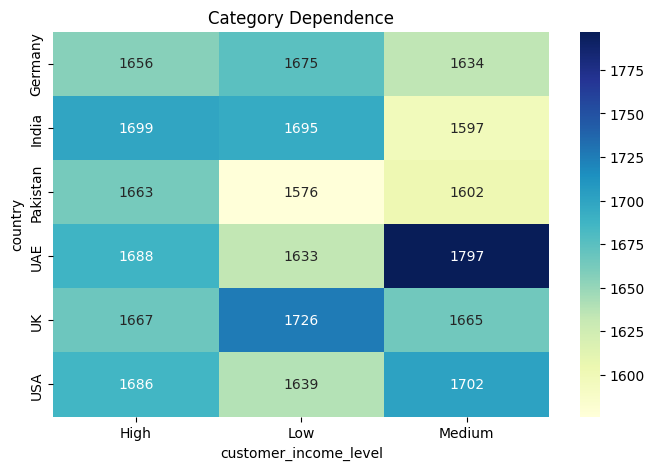

In [26]:
plt.figure(figsize=(8,5))

sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")

plt.title("Category Dependence")
plt.show()

**Висновки:**

*P-value = 0.0695 і залежності не виявлено. Оскільки значення p-value знаходиться близько до порогового рівня, це може свідчити про наявність слабкої тенденції, яка не підтвердилась через обмеження вибірки або високу однорідність даних. Варто провести додатковий аналіз із більш детальною сегментацією або збільшеним обсягом даних.*


# Загальні висновки

1. Ринок є стабільним і слабо сегментованим за доходом клієнтів, адже спортивне взуття є масовим продуктом, а не преміальним сегментом.
2. Географія не є ключовим показником найбільших продажів, що підтверджують показник ANOVA та χ²-тест. І значущих зв’язків між країною та доходом клієнта не виявлено, а от саме категорія товару, а не клієнтський профіль, визначає виручку.  
3. Ринок спортивного взуття не монополізований, а структурований за спеціалізаціями. Наприклад, Nike лідер взуття для Basketball, ASICS найстабільніший бренд у всіх категоріях, New Balance сильний у категоріях Running & Training, а от бренди Puma / Reebok є нішевими гравцями.
4. Немає цінової або поведінкової різниці між каналами продажу, та й знижки працюють як стимул обсягу, а не як радикальний фактор попиту. Загалом клієнти задоволені якість товарів і середня оцінка 4  для усіх представлених брендів.

# Рекомендації

1. Оптимізувати асортимент за категоріями, а не за сегментами клієнтів, тобто варто інвестувати в категорійне планування, а не демографічне таргетування.
2. Посилити бренд-стратегію через спеціалізацію, до прикладу для:
- Nike посилювати Basketball сегмент;
- ASICS підтримувати мультикатегоріальність;
- New Balance масштабувати Running/Training.
3. Оскільки середній чек приблизно однаковий, то варто оптимізувати логістику та UX, кастомізувати доступні методи оплати під кожен канал продажів.
4. Знижки впливають на обсяг продажів, але не радикально, тож має сенс використовувати таргетовані промо-акції замість масових знижок.

# 👟 Головний інсайт аналізу

Ринок спортивного взуття є глобально стабільним і слабо сегментованим за демографією. Основними драйверами виручки є категорія продукту та брендова спеціалізація, тоді як країна, дохід клієнта та канал продажу мають обмежений вплив на поведінку покупців.